# 🧠 Алгоритми та структури даних · Урок 5 — Графи

**Граф** — найуніверсальніша структура: соцмережі, карти доріг, залежності задач, інтернет,
рекомендації — усе це графи. Розберемо представлення графів і головні алгоритми: обходи (BFS/DFS),
топологічне сортування, найкоротші шляхи (Dijkstra, Bellman-Ford, Floyd-Warshall) та кістякові
дерева (MST).

**Передумова:** [Урок 2](lektsiya-2-bazovi-struktury-danykh.ipynb) (черга, стек),
[Урок 3](lektsiya-3-dereva-kupy-union-find.ipynb) (купа, Union-Find).

### Що ви вмітимете
- представляти граф **матрицею** та **списком суміжності**;
- робити **BFS** і **DFS**, знаходити найкоротший шлях у незваженому графі;
- робити **топологічне сортування**;
- знаходити найкоротші шляхи (**Dijkstra**) і **кістякове дерево** (Kruskal).

In [1]:
# 📊 Підготовка візуалізацій (matplotlib + networkx)
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
plt.rcParams["figure.dpi"] = 110

def draw_graph(edges, pos, directed=False, weights=None, highlight_edges=None,
               node_colors=None, title=""):
    G = (nx.DiGraph() if directed else nx.Graph())
    G.add_nodes_from(pos.keys())
    G.add_edges_from(edges)
    highlight_edges = set(highlight_edges or [])
    ncolors = [(node_colors or {}).get(v, "#90caf9") for v in G.nodes()]
    ecolors, widths = [], []
    for e in G.edges():
        hot = e in highlight_edges or (e[1], e[0]) in highlight_edges
        ecolors.append("#e53935" if hot else "#999")
        widths.append(3.0 if hot else 1.3)
    fig, ax = plt.subplots(figsize=(6.5, 4.6))
    nx.draw_networkx_nodes(G, pos, node_color=ncolors, node_size=900, edgecolors="#333", ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=ecolors, width=widths, ax=ax,
                           arrowsize=18, arrowstyle="-|>")
    nx.draw_networkx_labels(G, pos, font_size=11, ax=ax)
    if weights:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=weights, font_color="#c62828", ax=ax)
    ax.set_title(title); ax.axis("off")
    plt.show()

## 1. Що таке граф і які вони бувають

**Граф** = множина **вершин** (vertices/nodes) + множина **ребер** (edges), що їх з'єднують.

Види:
- **Ненапрямлений** (undirected) — ребро працює в обидва боки (дружба у соцмережі).
- **Напрямлений** (directed / digraph) — ребро має напрям (підписка, посилання).
- **Зважений** (weighted) — у ребра є «вага»/вартість (відстань, ціна).
- **DAG** (Directed Acyclic Graph) — напрямлений **без циклів** (залежності задач, збірка).
- **Циклічний** — містить цикл.

```
ненапрямлений        напрямлений (DAG)
   A —— B               A → B → D
   |  / |               ↓       ↑
   C —— D               C ──────┘
```

## 2. Представлення графів

Два основні способи:

### Матриця суміжності (adjacency matrix)
Таблиця n×n: `M[i][j] = 1` (або вага), якщо є ребро i→j.
- перевірка «чи є ребро» — **O(1)**;
- пам'ять — **O(n²)** (марнотратно для рідких графів).

### Список суміжності (adjacency list)
Для кожної вершини — список її сусідів. Найпоширеніший на практиці.
- пам'ять — **O(V + E)** (вершини + ребра);
- перебір сусідів — швидкий; перевірка конкретного ребра — O(степеня).

| | Матриця | Список |
|-|---------|--------|
| Пам'ять | O(V²) | O(V+E) |
| Є ребро (u,v)? | O(1) | O(deg u) |
| Перебір сусідів u | O(V) | O(deg u) |
| Коли | щільні графи | **рідкі графи (майже завжди)** |

In [2]:
# Граф як список суміжності (dict: вершина -> список сусідів)
graph = {
    "A": ["B", "C"],
    "B": ["A", "D"],
    "C": ["A", "D"],
    "D": ["B", "C", "E"],
    "E": ["D"],
}
print("сусіди D:", graph["D"])
print("кількість вершин:", len(graph))
print("кількість ребер (ненапрямлений):", sum(len(v) for v in graph.values()) // 2)

сусіди D: ['B', 'C', 'E']
кількість вершин: 5
кількість ребер (ненапрямлений): 5


📊 **Ось цей граф.** Далі ми обійдемо його через BFS та DFS.

/var/folders/f0/q5fr91kx2cq_wr0hd8lh0kvw0000gn/T/ipykernel_18885/2087965471.py:21: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for arrowstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edge_color=ecolors, width=widths, ax=ax,


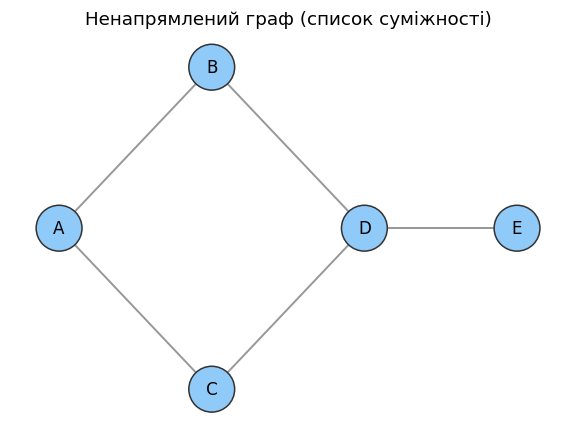

In [3]:
# Ненапрямлений граф із прикладу (сусіди A..E)
pos = {"A": (0, 1), "B": (1, 2), "C": (1, 0), "D": (2, 1), "E": (3, 1)}
edges = [("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"), ("D", "E")]
draw_graph(edges, pos, title="Ненапрямлений граф (список суміжності)")

## 3. Обходи: BFS та DFS

Два способи систематично відвідати всі вершини:

- **BFS (обхід у ширину)** — від старту йдемо «колами»: спершу всі сусіди, потім сусіди сусідів.
  Використовує **чергу**. Знаходить **найкоротший шлях** у **незваженому** графі.
- **DFS (обхід у глибину)** — йдемо якомога глибше однією гілкою, потім повертаємось (backtrack).
  Використовує **стек** (або рекурсію). Основа топологічного сортування, пошуку циклів, компонент.

Обидва — **O(V + E)**. Ключове — множина `visited`, щоб не зациклитись.

In [4]:
from collections import deque

def bfs(graph, start):
    visited = {start}
    order, q = [], deque([start])
    while q:
        node = q.popleft()               # черга -> у ширину
        order.append(node)
        for nb in graph[node]:
            if nb not in visited:
                visited.add(nb)
                q.append(nb)
    return order

def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited, order = set(), []
    visited.add(start)
    order.append(start)
    for nb in graph[start]:              # рекурсія -> у глибину
        if nb not in visited:
            dfs(graph, nb, visited, order)
    return order

graph = {
    "A": ["B", "C"], "B": ["A", "D"], "C": ["A", "D"],
    "D": ["B", "C", "E"], "E": ["D"],
}
print("BFS від A:", bfs(graph, "A"))
print("DFS від A:", dfs(graph, "A"))

BFS від A: ['A', 'B', 'C', 'D', 'E']
DFS від A: ['A', 'B', 'D', 'C', 'E']


### BFS для найкоротшого шляху (незважений граф)
Оскільки BFS відвідує вершини «колами» за відстанню, він природно знаходить **найменшу кількість
ребер** до кожної вершини. Запам'ятовуємо, звідки прийшли (`parent`), щоб відновити шлях.

In [5]:
from collections import deque

def shortest_path(graph, start, goal):
    if start == goal:
        return [start]
    visited = {start}
    parent = {start: None}
    q = deque([start])
    while q:
        node = q.popleft()
        for nb in graph[node]:
            if nb not in visited:
                visited.add(nb)
                parent[nb] = node
                if nb == goal:                     # знайшли -> відновлюємо шлях назад
                    path = [goal]
                    while parent[path[-1]] is not None:
                        path.append(parent[path[-1]])
                    return path[::-1]
                q.append(nb)
    return None                                    # шляху немає

graph = {
    "A": ["B", "C"], "B": ["A", "D"], "C": ["A", "D"],
    "D": ["B", "C", "E"], "E": ["D"],
}
print("найкоротший A -> E:", shortest_path(graph, "A", "E"))   # A B D E (або A C D E)

найкоротший A -> E: ['A', 'B', 'D', 'E']


## 4. Топологічне сортування (для DAG)

**Топологічне сортування** упорядковує вершини напрямленого **ациклічного** графа так, що кожне
ребро u→v йде «зліва направо» (u перед v). Це «порядок виконання із залежностями»: збірка проєкту,
розклад курсів, розв'язання залежностей пакетів.

**Алгоритм Кана (Kahn):** беремо вершини з **нульовим вхідним степенем** (немає залежностей),
прибираємо їх, зменшуємо степені сусідів, повторюємо. Якщо лишились вершини — у графі **цикл**.

In [6]:
from collections import deque

def topological_sort(graph):
    indeg = {u: 0 for u in graph}
    for u in graph:
        for v in graph[u]:
            indeg[v] += 1                       # рахуємо вхідні степені
    q = deque([u for u in graph if indeg[u] == 0])   # старт: без залежностей
    order = []
    while q:
        u = q.popleft()
        order.append(u)
        for v in graph[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                q.append(v)
    if len(order) != len(graph):
        return None                             # лишились вершини -> є цикл
    return order

# Залежності задач: щоб зробити ключ, спершу треба попередні
tasks = {
    "встати": ["вмитися", "кава"],
    "вмитися": ["одягнутися"],
    "кава": ["одягнутися"],
    "одягнутися": ["вийти"],
    "вийти": [],
}
print("порядок виконання:", topological_sort(tasks))

порядок виконання: ['встати', 'вмитися', 'кава', 'одягнутися', 'вийти']


## 5. Найкоротші шляхи у зважених графах

| Алгоритм | Що знаходить | Ваги | Складність |
|----------|-------------|------|-----------|
| **BFS** | найкоротший шлях | незважений | O(V+E) |
| **Dijkstra** | від однієї вершини до всіх | **невід'ємні** | O((V+E)·log V) з купою |
| **Bellman-Ford** | від однієї до всіх | можуть бути **від'ємні** | O(V·E) |
| **Floyd-Warshall** | між **усіма** парами | будь-які (без від'ємних циклів) | O(V³) |

**Dijkstra** — «жадібний»: щоразу бере найближчу ще не оброблену вершину (через **купу** з Уроку 3)
і «розслабляє» (relax) ребра до сусідів. Не працює з **від'ємними** вагами — для них Bellman-Ford.

In [7]:
import heapq

def dijkstra(graph, start):
    # graph: вершина -> список (сусід, вага)
    dist = {v: float("inf") for v in graph}
    dist[start] = 0
    pq = [(0, start)]                          # купа (відстань, вершина)
    while pq:
        d, u = heapq.heappop(pq)               # найближча необроблена
        if d > dist[u]:
            continue                           # застаріла копія — пропускаємо
        for v, w in graph[u]:
            nd = d + w
            if nd < dist[v]:                   # relax: знайшли коротший шлях до v
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
    return dist

weighted = {
    "A": [("B", 1), ("C", 4)],
    "B": [("C", 2), ("D", 5)],
    "C": [("D", 1)],
    "D": [],
}
print("найкоротші відстані від A:", dijkstra(weighted, "A"))
# A->B=1, A->C=3 (через B), A->D=4 (A->B->C->D)

найкоротші відстані від A: {'A': 0, 'B': 1, 'C': 3, 'D': 4}


📊 **Зважений граф і результат Dijkstra.** Червоним підсвічено найкоротший шлях A→D вагою 4 (A→B→C→D = 1+2+1), а не пряме A→C→D.

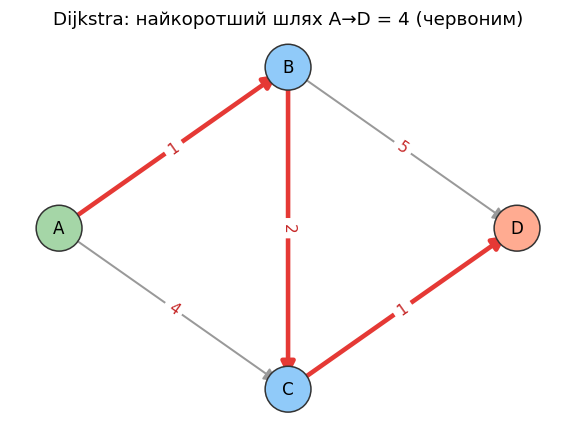

In [8]:
# Зважений напрямлений граф для Dijkstra + підсвічений найкоротший шлях A->D
pos = {"A": (0, 1), "B": (1, 1.8), "C": (1, 0.2), "D": (2, 1)}
edges = [("A", "B"), ("A", "C"), ("B", "C"), ("B", "D"), ("C", "D")]
weights = {("A", "B"): 1, ("A", "C"): 4, ("B", "C"): 2, ("B", "D"): 5, ("C", "D"): 1}
# найкоротший A->D = A->B->C->D (1+2+1 = 4)
path_edges = [("A", "B"), ("B", "C"), ("C", "D")]
draw_graph(edges, pos, directed=True, weights=weights, highlight_edges=path_edges,
           node_colors={"A": "#a5d6a7", "D": "#ffab91"},
           title="Dijkstra: найкоротший шлях A→D = 4 (червоним)")

## 6. Кістякове дерево мінімальної ваги (MST)

**MST (Minimum Spanning Tree)** — підмножина ребер, що з'єднує **всі** вершини з **мінімальною**
сумарною вагою і **без циклів** (прокласти дороги/кабель між містами найдешевше).

- **Kruskal** — сортуємо ребра за вагою й додаємо по одному, пропускаючи ті, що утворюють цикл
  (цикл перевіряємо через **Union-Find** з Уроку 3). O(E log E).
- **Prim** — «нарощуємо» дерево від однієї вершини, щоразу додаючи найдешевше ребро назовні (через
  купу). O(E log V).

In [9]:
class UnionFind:
    def __init__(self, nodes):
        self.parent = {x: x for x in nodes}
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False                       # уже з'єднані -> ребро дало б цикл
        self.parent[rb] = ra
        return True

def kruskal(nodes, edges):
    # edges: список (вага, u, v)
    uf = UnionFind(nodes)
    mst, total = [], 0
    for w, u, v in sorted(edges):              # ребра за зростанням ваги
        if uf.union(u, v):                     # додаємо, якщо не утворює цикл
            mst.append((u, v, w))
            total += w
    return mst, total

nodes = ["A", "B", "C", "D"]
edges = [(1, "A", "B"), (4, "A", "C"), (2, "B", "C"), (5, "B", "D"), (1, "C", "D")]
mst, total = kruskal(nodes, edges)
print("ребра MST:", mst)
print("сумарна вага:", total)                  # 1(A-B)+2(B-C)+1(C-D)=4

ребра MST: [('A', 'B', 1), ('C', 'D', 1), ('B', 'C', 2)]
сумарна вага: 4


📊 **Кістякове дерево мінімальної ваги.** Червоні ребра з'єднують усі вершини найдешевше (вага 4), без циклів; дорогі ребра A–C (4) та B–D (5) не увійшли.

/var/folders/f0/q5fr91kx2cq_wr0hd8lh0kvw0000gn/T/ipykernel_18885/2087965471.py:21: UserWarning: 

The arrowstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for arrowstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G, pos, edge_color=ecolors, width=widths, ax=ax,


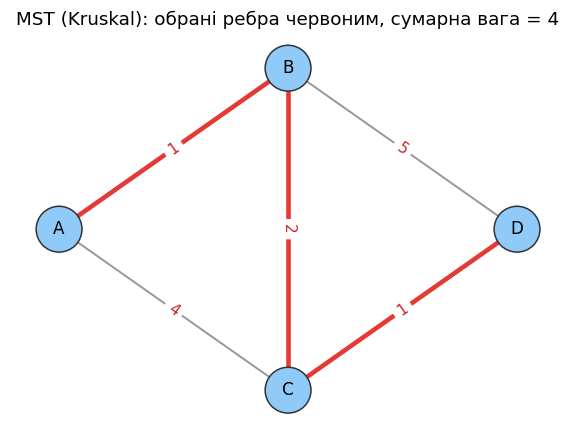

In [10]:
# Кістякове дерево (MST) з прикладу Kruskal — підсвічені обрані ребра
pos = {"A": (0, 1), "B": (1, 1.8), "C": (1, 0.2), "D": (2, 1)}
edges = [("A", "B"), ("A", "C"), ("B", "C"), ("B", "D"), ("C", "D")]
weights = {("A", "B"): 1, ("A", "C"): 4, ("B", "C"): 2, ("B", "D"): 5, ("C", "D"): 1}
mst_edges = [("A", "B"), ("B", "C"), ("C", "D")]   # сумарна вага 1+2+1 = 4
draw_graph(edges, pos, weights=weights, highlight_edges=mst_edges,
           title="MST (Kruskal): обрані ребра червоним, сумарна вага = 4")

> 🎯 **Часті питання на співбесіді про графи:**
> - **BFS чи DFS для найкоротшого шляху?** BFS (у незваженому графі). DFS не гарантує найкоротший.
> - **Чому Dijkstra не працює з від'ємними вагами?** Він «закриває» вершину назавжди, узявши її як
>   найближчу; від'ємне ребро могло б згодом дати коротший шлях — інваріант ламається. → Bellman-Ford.
> - **Матриця чи список суміжності?** Список — майже завжди (пам'ять O(V+E)); матриця — для щільних
>   графів або коли часто питають «чи є ребро».

# ✅ Підсумок уроку
- **Граф** = вершини + ребра; буває напрямлений/ненапрямлений, зважений, DAG.
- **Представлення:** список суміжності (O(V+E), майже завжди) чи матриця (O(V²), щільні графи).
- **BFS** (черга) — обхід у ширину + найкоротший шлях у **незваженому**; **DFS** (стек/рекурсія) — у глибину.
- **Топологічне сортування** (Kahn) — порядок для DAG; лишок вершин ⇒ цикл.
- **Найкоротші шляхи:** Dijkstra (невід'ємні ваги, купа), Bellman-Ford (від'ємні), Floyd-Warshall (усі пари).
- **MST:** Kruskal (сортування ребер + Union-Find) або Prim (нарощування з купою).

### ▶️ Далі
Урок 6 — **парадигми проєктування алгоритмів** (розділяй і володарюй, жадібні, динамічне
програмування, backtracking).

### 📚 Хочу знати більше
- Візуалізації графів: <https://visualgo.net/en/graphds>
- CP-Algorithms (графи): <https://cp-algorithms.com/>
- Dijkstra та ін. (NeetCode): <https://neetcode.io/>